# Pandas and Visualisation Recap
This notebook gives you a refresh on the pandas essentials needed for ML and data science workflows.

We focus on:
- Inspecting & understanding data  
- Accessing rows/columns  
- Cleaning & preprocessing  
- Joining  
- Groupby  
- Feature engineering

Good Pandas tutorials

https://www.w3schools.com/python/pandas/default.asp

https://www.geeksforgeeks.org/pandas/pandas-tutorial/

Good Numpy tutorial
https://www.w3schools.com/python/numpy/default.asp

 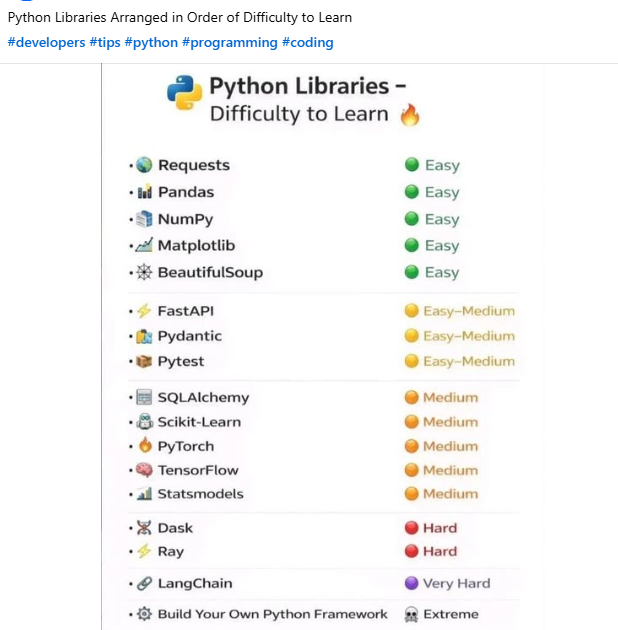

---

## 1. Reading and Inspecting Data

- `pd.read_csv()` / `read_excel()`
-  
- `.head()`, `.info()`, `.describe()`
- Checking dtypes and spotting object-vs-int issues
note you can import other file formats such as excel, json etc

In [1]:
import pandas as pd

In [2]:
titanic = pd.read_csv("data/titanic.csv")
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,11
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",135.0,NaN
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN


In [3]:
titanic.tail(10)
# shows the last ten rows
#sibsp is the number of siblings and spouse
#parch how many parents and children on board
# body Contains an identification number for the passenger's body if they did not survive and their body was subsequently recovered. 
# boat Identifies the specific lifeboat a passenger was on if they survived the sinking.
# NaN Not a Number

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
1300,3.0,1.0,"Yasbeck, Mrs. Antoni (Selini Alexander)",female,15.0,1.0,0.0,2659,14.4542,NaN,C,NaN,NaN,NaN
1301,3.0,0.0,"Youseff, Mr. Gerious",male,45.5,0.0,0.0,2628,7.2250,NaN,C,NaN,312.0,NaN
1302,3.0,0.0,"Yousif, Mr. Wazli",male,NaN,0.0,0.0,2647,7.2250,NaN,C,NaN,NaN,NaN
1303,3.0,0.0,"Yousseff, Mr. Gerious",male,NaN,0.0,0.0,2627,14.4583,NaN,C,NaN,NaN,NaN
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5,1.0,0.0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5,0.0,0.0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0,0.0,0.0,2670,7.2250,NaN,C,NaN,NaN,NaN
1308,3.0,0.0,"Zimmerman, Mr. Leo",male,29.0,0.0,0.0,315082,7.8750,NaN,S,NaN,NaN,NaN
1309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
titanic.info()
#
# float64 is a floating point (decimals)
#object =any type used as a default the catch-all; including numbers, strings of characters, lists, functions 
#Int64 whole numbers 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  home.dest  745 non-null    object 
 12  body       121 non-null    float64
 13  boat       486 non-null    object 
dtypes: float64(7), object(7)
memory usage: 143.4+ KB


1310 rows
object is a default for Python.
Do all object types look as they should?
survived - 1 or 0 integer or boolean
parent/children integer



In [5]:
titanic.describe()
# indicates further information which may show you what needs to be changed.
#The 25th percentile is the value below which 25% of the data falls.
#Quartiles → split data into 4 equal parts (25% and 75%)
# 50%  is the median value

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [6]:
titanic['age'].describe()

count    1046.000000
mean       29.881135
std        14.413500
min         0.166700
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

In [7]:
titanic.dtypes

pclass       float64
survived     float64
name          object
sex           object
age          float64
sibsp        float64
parch        float64
ticket        object
fare         float64
cabin         object
embarked      object
home.dest     object
body         float64
boat          object
dtype: object

In [8]:
titanic.isna().sum()
# gives the total number of missing values -isna() is not available

pclass          1
survived        1
name            1
sex             1
age           264
sibsp           1
parch           1
ticket          1
fare            2
cabin        1015
embarked        3
home.dest     565
body         1189
boat          824
dtype: int64

In [9]:
titanic.isnull().sum()
# isnull does the same as isna 

pclass          1
survived        1
name            1
sex             1
age           264
sibsp           1
parch           1
ticket          1
fare            2
cabin        1015
embarked        3
home.dest     565
body         1189
boat          824
dtype: int64

### Task
- Load the dataset animals.csv.

- Show the first 5 rows.

- Check the dtypes.

- Identify any problems (object columns that should be numeric/datetime).

In [10]:
#ANSWER
animals = pd.read_csv("data/animals.csv")

#1. First 8 rows
#animals.head(8)

# 2. Identify missing values
#animals.isna().sum()

# 3. Check dtypes
#animals.dtypes

# NOTE THAT Ctrl /  comments all the rows you highlighted (quick way of converting code to comments)
#dateTimeofCall should be date/time, hourly nominal cost should be a float.


## 2. Selecting Data: loc, iloc, boolean filters

`.loc` - label-based (using the name of the column)

`.iloc` - position-based (the rows position and column position) index bvased positioning

Boolean filters are essential for feature engineering and cleaning
Feature engineering is the process of transforming raw data into meaningful features that improve the performance of machine learning (ML) models.

In [11]:
# Rows where value > 50
titanic.loc[titanic["age"] > 50]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
6,1.0,1.0,"Andrews, Miss. Kornelia Theodosia",female,63.0,1.0,0.0,13502,77.9583,D7,S,"Hudson, NY",NaN,10
8,1.0,1.0,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2.0,0.0,11769,51.4792,C101,S,"Bayside, Queens, NY",NaN,D
9,1.0,0.0,"Artagaveytia, Mr. Ramon",male,71.0,0.0,0.0,PC 17609,49.5042,NaN,C,"Montevideo, Uruguay",22.0,NaN
14,1.0,1.0,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0.0,0.0,27042,30.0000,A23,S,"Hessle, Yorks",NaN,B
33,1.0,1.0,"Bonnell, Miss. Elizabeth",female,58.0,0.0,0.0,113783,26.5500,C103,S,"Birkdale, England Cleveland, Ohio",NaN,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1068,3.0,0.0,"Nysveen, Mr. Johan Hansen",male,61.0,0.0,0.0,345364,6.2375,NaN,S,NaN,NaN,NaN
1225,3.0,0.0,"Storey, Mr. Thomas",male,60.5,0.0,0.0,3701,NaN,NaN,S,NaN,261.0,NaN
1235,3.0,0.0,"Svensson, Mr. Johan",male,74.0,0.0,0.0,347060,7.7750,NaN,S,NaN,NaN,NaN
1261,3.0,1.0,"Turkula, Mrs. (Hedwig)",female,63.0,0.0,0.0,4134,9.5875,NaN,S,NaN,NaN,15


In [12]:
# Using loc
titanic.loc[titanic["sex"] == "female"]
#== means 'is equal to' you are not assigning a value

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN
6,1.0,1.0,"Andrews, Miss. Kornelia Theodosia",female,63.0,1.0,0.0,13502,77.9583,D7,S,"Hudson, NY",NaN,10
8,1.0,1.0,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2.0,0.0,11769,51.4792,C101,S,"Bayside, Queens, NY",NaN,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1286,3.0,1.0,"Whabee, Mrs. George Joseph (Shawneene Abi-Saab)",female,38.0,0.0,0.0,2688,7.2292,NaN,C,NaN,NaN,C
1290,3.0,1.0,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1.0,0.0,363272,7.0000,NaN,S,NaN,NaN,NaN
1300,3.0,1.0,"Yasbeck, Mrs. Antoni (Selini Alexander)",female,15.0,1.0,0.0,2659,14.4542,NaN,C,NaN,NaN,NaN
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5,1.0,0.0,2665,14.4542,NaN,C,NaN,328.0,NaN


In [13]:
# Using iloc
titanic.iloc[0:2]
# start at first record and show 2 records

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,11


In [14]:
titanic.iloc[0:3, 0:4]

,pclass,survived,name,sex
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female
1,1.0,1.0,"Allison, Master. Hudson Trevor",male
2,1.0,0.0,"Allison, Miss. Helen Loraine",female


Above shows first three records and 4 columns

### Task
- Select all incidents where PumpCount is greater than 1.

- Using loc, show IncidentNumber, AnimalGroupParent, and Borough for incidents involving "Cat".

- Using iloc, return rows 20–40 and the first 4 columns.

In [15]:
# ANSWERS
#animals[animals["PumpCount"] > 1]

#animals.loc[animals["AnimalGroupParent"] == "Cat", ["IncidentNumber", "AnimalGroupParent", "Borough"]]

#animals.iloc[20:41, 0:4]

## 3. Cleaning & Preprocessing
Common operations:
- Handling missing values
- Fixing dtypes
- String cleaning (Changing to lowercase etc)
- Converting to datetime (if present)
- There are LOTS of ways of cleaning (only a few shown here)

In [16]:
#Fill missing ages
titanic["age"] = titanic["age"].fillna(titanic["age"].median())

# What’s happening:
# •	titanic["age"] → selects the age column
# .median() → calculates the middle value of all known ages
# .fillna(...) → replaces missing values (NaN) with that median
#
# Why median rather than the mean?


# Ages can have outliers (very young or very old passengers)
#The median is less affected by extreme values than the mean (average)
# because it represents the middle position of an ordered dataset, whereas the mean is 
# calculated using the magnitude of every data point. Outliers or skewed data strongly 
# pull the mean but have little to no effect on the median


In [17]:
# Fill missing Embarked values
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])
# Why are you using the mode not the mean or median here?

In [18]:
# titanic["embarked"]
# This selects the Embarked column from the titanic DataFrame.
#Typical values might be:
#	"S" (Southampton)
#	"C" (Cherbourg)
#	"Q" (Queenstown)
#	NaN (missing)
#Find the most common value
#titanic["embarked"].mode()
#	.mode() returns the most frequently occurring value(s)
#	For example, it might return:  S  (Southampton)
#Because .mode() returns a Series, not a single value, we use: .mode()[0]
#This means:
# “Give me the first (most common) value.”
#
#Fill missing values
#.fillna(titanic["embarked"].mode()[0])
#.fillna() replaces all NaN (missing) values
#The replacement value is the most common embarkation point
#Assign it back to the column
#titanic["embarked"] = ...
#embarked is categorical data (text, not numbers)
#You can’t use mean or median on categories
#The safest assumption for missing categories is the most frequent value


In [19]:
# Standardise strings
titanic["name"] = titanic["name"].str.lower()

In [20]:
#converts all text in name field to lowercase
#when you search data on name then you will find all instances not only lowercase or uppercase names

In [21]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat
0,1.0,1.0,"allen, miss. elisabeth walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2
1,1.0,1.0,"allison, master. hudson trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,11
2,1.0,0.0,"allison, miss. helen loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN
3,1.0,0.0,"allison, mr. hudson joshua creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",135.0,NaN
4,1.0,0.0,"allison, mrs. hudson j c (bessie waldo daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN


### Tasks
- Fill missing PumpHoursTotal values with the median.

- Convert Borough to title case and strip whitespace.    - (try googling to see if you can find how to do this)

- Ensure AnimalGroupParent is lowercase (for consistency).

In [22]:
#aNSWERS
animals["PumpHoursTotal"] = animals["PumpHoursTotal"].fillna(
    animals["PumpHoursTotal"].median()
)

animals["Borough"] = animals["Borough"].str.strip().str.title()

animals["AnimalGroupParent"] = animals["AnimalGroupParent"].str.lower()
animals.head()

,IncidentNumber,DateTimeOfCall,CalYear,FinYear,TypeOfIncident,PumpCount,PumpHoursTotal,HourlyNominalCost(£),IncidentNominalCost(£),FinalDescription,AnimalGroupParent,PropertyType,SpecialServiceTypeCategory,SpecialServiceType,Borough,StnGroundName,AnimalClass,Code,London
0,139091,01/01/2009 03:01,2009,2008/09,Special Service,1.0,2.0,255,510.0,"DOG WITH JAW TRAPPED IN MAGAZINE RACK,B15",dog,House - single occupancy,Other animal assistance,Animal assistance involving livestock - Other ...,Croydon,Norbury,Mammal,00AH,Outer London
1,275091,01/01/2009 08:51,2009,2008/09,Special Service,1.0,1.0,255,255.0,"ASSIST RSPCA WITH FOX TRAPPED,B15",fox,Railings,Other animal assistance,Animal assistance involving livestock - Other ...,Croydon,Woodside,Mammal,00AH,Outer London
2,2075091,04/01/2009 10:07,2009,2008/09,Special Service,1.0,1.0,255,255.0,"DOG CAUGHT IN DRAIN,B15",dog,Pipe or drain,Animal rescue from below ground,Animal rescue from below ground - Domestic pet,Sutton,Wallington,Mammal,00BF,Outer London
3,2872091,05/01/2009 12:27,2009,2008/09,Special Service,1.0,1.0,255,255.0,"HORSE TRAPPED IN LAKE,J17",horse,"Intensive Farming Sheds (chickens, pigs etc)",Animal rescue from water,Animal rescue from water - Farm animal,Hillingdon,Ruislip,Mammal,00AS,Outer London
4,3553091,06/01/2009 15:23,2009,2008/09,Special Service,1.0,1.0,255,255.0,"RABBIT TRAPPED UNDER SOFA,B15",rabbit,House - single occupancy,Other animal assistance,Animal assistance involving livestock - Other ...,Havering,Harold Hill,Mammal,00AR,Outer London


## 4. Joining DataFrames (merge + concat)

`merge()` for adding extra info (adding extra columns)

`concat()` for stacking datasets (adding extra rows)

https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf

In [23]:
pclass_info = pd.DataFrame({
    "pclass": [1,2,3],
    "class_description": ["Upper", "Middle", "Lower"]
})
pclass_info.head()


,pclass,class_description
0,1,Upper
1,2,Middle
2,3,Lower


In [24]:
#the following merges this into the dataframe

merged = titanic.merge(pclass_info, on="pclass", how="left")
#if you don't specify the type of join (left here) then it will do an inner join
# make sure you have a basic understanding of joins
merged.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat,class_description
0,1.0,1.0,"allen, miss. elisabeth walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2,Upper
1,1.0,1.0,"allison, master. hudson trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,11,Upper
2,1.0,0.0,"allison, miss. helen loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN,Upper
3,1.0,0.0,"allison, mr. hudson joshua creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",135.0,NaN,Upper
4,1.0,0.0,"allison, mrs. hudson j c (bessie waldo daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN,Upper


### Task
Merge the below lookup table into the animals dataframe.

In [25]:
animalclass_info = pd.DataFrame({
    "AnimalClass": ["Mammal", "Bird", "Reptile", "Fish"],
    "TemperatureType": ["Warm-blooded", "Warm-blooded", "Cold-blooded", "Cold-blooded"]
})

In [26]:
#ANSWER
#
animals_merged = animals.merge(animalclass_info, on="AnimalClass", how="left")
#created animals_merged so we don't have two dataframes witht the same name
animals_merged.head()

,IncidentNumber,DateTimeOfCall,CalYear,FinYear,TypeOfIncident,PumpCount,PumpHoursTotal,HourlyNominalCost(£),IncidentNominalCost(£),FinalDescription,AnimalGroupParent,PropertyType,SpecialServiceTypeCategory,SpecialServiceType,Borough,StnGroundName,AnimalClass,Code,London,TemperatureType
0,139091,01/01/2009 03:01,2009,2008/09,Special Service,1.0,2.0,255,510.0,"DOG WITH JAW TRAPPED IN MAGAZINE RACK,B15",dog,House - single occupancy,Other animal assistance,Animal assistance involving livestock - Other ...,Croydon,Norbury,Mammal,00AH,Outer London,Warm-blooded
1,275091,01/01/2009 08:51,2009,2008/09,Special Service,1.0,1.0,255,255.0,"ASSIST RSPCA WITH FOX TRAPPED,B15",fox,Railings,Other animal assistance,Animal assistance involving livestock - Other ...,Croydon,Woodside,Mammal,00AH,Outer London,Warm-blooded
2,2075091,04/01/2009 10:07,2009,2008/09,Special Service,1.0,1.0,255,255.0,"DOG CAUGHT IN DRAIN,B15",dog,Pipe or drain,Animal rescue from below ground,Animal rescue from below ground - Domestic pet,Sutton,Wallington,Mammal,00BF,Outer London,Warm-blooded
3,2872091,05/01/2009 12:27,2009,2008/09,Special Service,1.0,1.0,255,255.0,"HORSE TRAPPED IN LAKE,J17",horse,"Intensive Farming Sheds (chickens, pigs etc)",Animal rescue from water,Animal rescue from water - Farm animal,Hillingdon,Ruislip,Mammal,00AS,Outer London,Warm-blooded
4,3553091,06/01/2009 15:23,2009,2008/09,Special Service,1.0,1.0,255,255.0,"RABBIT TRAPPED UNDER SOFA,B15",rabbit,House - single occupancy,Other animal assistance,Animal assistance involving livestock - Other ...,Havering,Harold Hill,Mammal,00AR,Outer London,Warm-blooded


## 5. Groupby & Aggregation
Useful for summarising the following from the dataframe:
- Means

- Totals

- Counts

In [27]:
titanic.groupby("sex")["survived"].mean()
#calculates the mean of the survived - 72% of the females survived 

sex
female    0.727468
male      0.190985
Name: survived, dtype: float64

This works because the survived column only contains 0 and 1:

1 = survived

0 = did not survive

When you take the mean (average) of 0s and 1s, you get the proportion of 1s, which is the percentage that survived.

In [28]:
titanic.groupby("sex")["survived"].sum()
#How many survivors are in each group
#this sums up all of the 1's (survived) 

sex
female    339.0
male      161.0
Name: survived, dtype: float64

In [29]:
titanic.groupby("sex")["survived"].count()
#counts all of the non missing rows for survived (thus it counts both 0's and 1's)
#

sex
female    466
male      843
Name: survived, dtype: int64

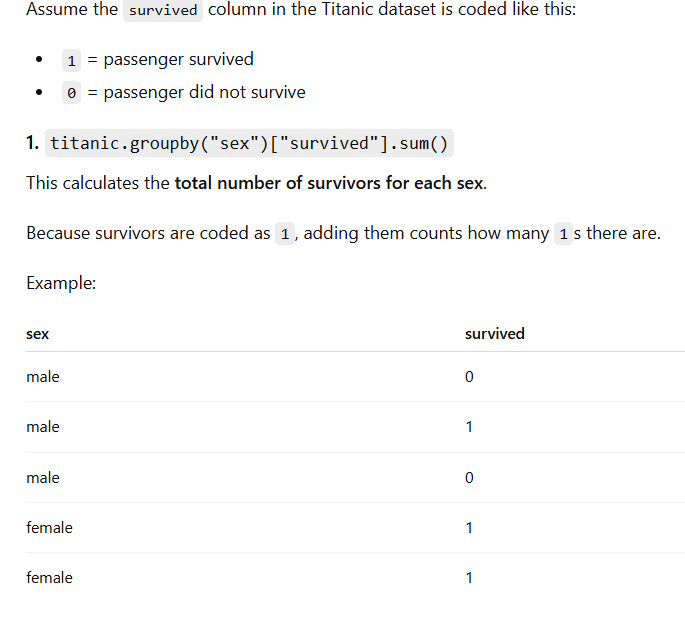
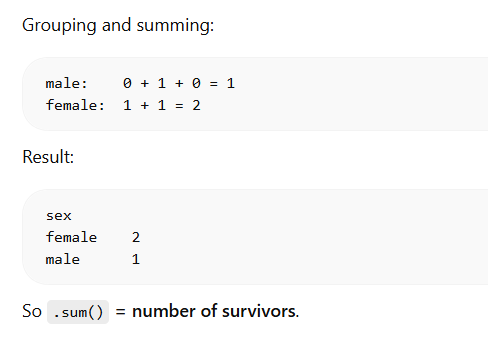
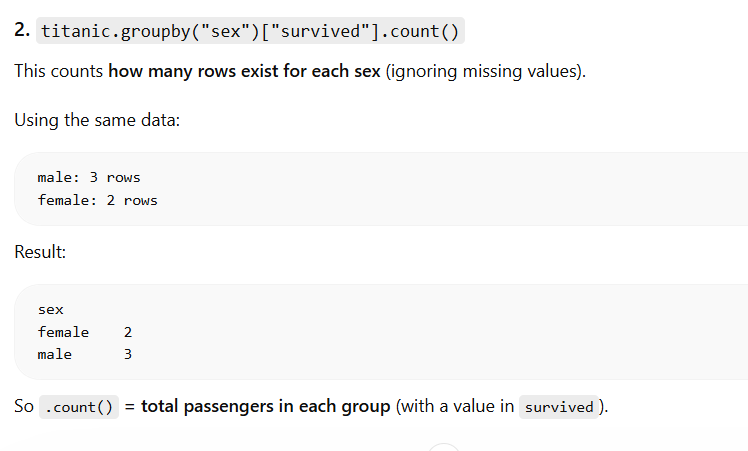

### Tasks

- Find the number of incidents per AnimalGroupParent. (use count)

- Compute the average incident cost (IncidentNominalCost(£)) per Borough. (use mean)

- Find the total PumpHoursTotal per TypeOfIncident. (use sum)

In [30]:
#ANSWERWS

#animals.groupby("AnimalGroupParent")["IncidentNumber"].count()

#animals.groupby("Borough")["IncidentNominalCost(£)"].mean()

animals.groupby("TypeOfIncident")["PumpHoursTotal"].sum()


TypeOfIncident
Special Service    6811.0
Name: PumpHoursTotal, dtype: float64

## 6. Feature Engineering
New columns, binning, mappings, ratios. (Again there are lots of features this is just an example)

Binning (also called bucketing or discretization) is a very common feature engineering technique used to convert continuous numerical variables into discrete categories (bins/intervals)

Mappings in feature engineering are techniques that transform raw, complex, or categorical data into numerical representations (vectors) suitable for machine learning algorithms.

Ratios in feature engineering are new features created by dividing one variable by another. 


In [31]:
titanic["familysize"] = titanic["sibsp"] + titanic["parch"] + 1
titanic.head()


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,body,boat,familysize
0,1.0,1.0,"allen, miss. elisabeth walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO",NaN,2,1.0
1,1.0,1.0,"allison, master. hudson trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,11,4.0
2,1.0,0.0,"allison, miss. helen loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN,4.0
3,1.0,0.0,"allison, mr. hudson joshua creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",135.0,NaN,4.0
4,1.0,0.0,"allison, mrs. hudson j c (bessie waldo daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON",NaN,NaN,4.0


A sibling is a relative that shares at least one parent with the other person. A male sibling is a brother, and a female sibling is a sister. A person with no siblings is an only child.

In [32]:
#all changes made so far haven't been saved to the CSV file. to do this do the following
#titanic.to_CSV("titanic1.CSV")

### Task
Create a feature CostPerPumpHour = IncidentNominalCost(£) / PumpHoursTotal.

In [33]:
# ANSWER
animals["CostPerPumpHour"] = animals["IncidentNominalCost(£)"] / animals["PumpHoursTotal"]
animals.head()

,IncidentNumber,DateTimeOfCall,CalYear,FinYear,TypeOfIncident,PumpCount,PumpHoursTotal,HourlyNominalCost(£),IncidentNominalCost(£),FinalDescription,AnimalGroupParent,PropertyType,SpecialServiceTypeCategory,SpecialServiceType,Borough,StnGroundName,AnimalClass,Code,London,CostPerPumpHour
0,139091,01/01/2009 03:01,2009,2008/09,Special Service,1.0,2.0,255,510.0,"DOG WITH JAW TRAPPED IN MAGAZINE RACK,B15",dog,House - single occupancy,Other animal assistance,Animal assistance involving livestock - Other ...,Croydon,Norbury,Mammal,00AH,Outer London,255.0
1,275091,01/01/2009 08:51,2009,2008/09,Special Service,1.0,1.0,255,255.0,"ASSIST RSPCA WITH FOX TRAPPED,B15",fox,Railings,Other animal assistance,Animal assistance involving livestock - Other ...,Croydon,Woodside,Mammal,00AH,Outer London,255.0
2,2075091,04/01/2009 10:07,2009,2008/09,Special Service,1.0,1.0,255,255.0,"DOG CAUGHT IN DRAIN,B15",dog,Pipe or drain,Animal rescue from below ground,Animal rescue from below ground - Domestic pet,Sutton,Wallington,Mammal,00BF,Outer London,255.0
3,2872091,05/01/2009 12:27,2009,2008/09,Special Service,1.0,1.0,255,255.0,"HORSE TRAPPED IN LAKE,J17",horse,"Intensive Farming Sheds (chickens, pigs etc)",Animal rescue from water,Animal rescue from water - Farm animal,Hillingdon,Ruislip,Mammal,00AS,Outer London,255.0
4,3553091,06/01/2009 15:23,2009,2008/09,Special Service,1.0,1.0,255,255.0,"RABBIT TRAPPED UNDER SOFA,B15",rabbit,House - single occupancy,Other animal assistance,Animal assistance involving livestock - Other ...,Havering,Harold Hill,Mammal,00AR,Outer London,255.0


## 7. Seaborn Recap

Seaborn is a powerful and versatile data visualization library in Python, built on top of 
Matplotlib and closely integrated with Pandas data structures. It provides a high-level 
interface for creating attractive and informative statistical graphics, making it easier to  explore and understand your data.

Seaborn tutorial

https://seaborn.pydata.org/tutorial.html




In [34]:

#Seaborn
import seaborn as sns
import matplotlib.pyplot as plt
#Seaborn is built on top of Matplotlib
sns.set_theme(style="whitegrid")
#this is optional however it importing a theme into matplotlib (looks nicer)
# themes are things like background colour, grid lines, fonts, and spacing
# see the seaborn themes.doxs folder in this week's folder  2.4
# also https://python-graph-gallery.com/104-seaborn-themes/


### A. Categorical Plots
- Countplot (basically a barchart)
- Barplot
- Coloured by hue

The primary difference between a barplot and a countplot is that a barplot typically displays the mean or another aggregate statistic of a numerical variable across categoriesand a countplot shows the frequency (count) of observations in each category,


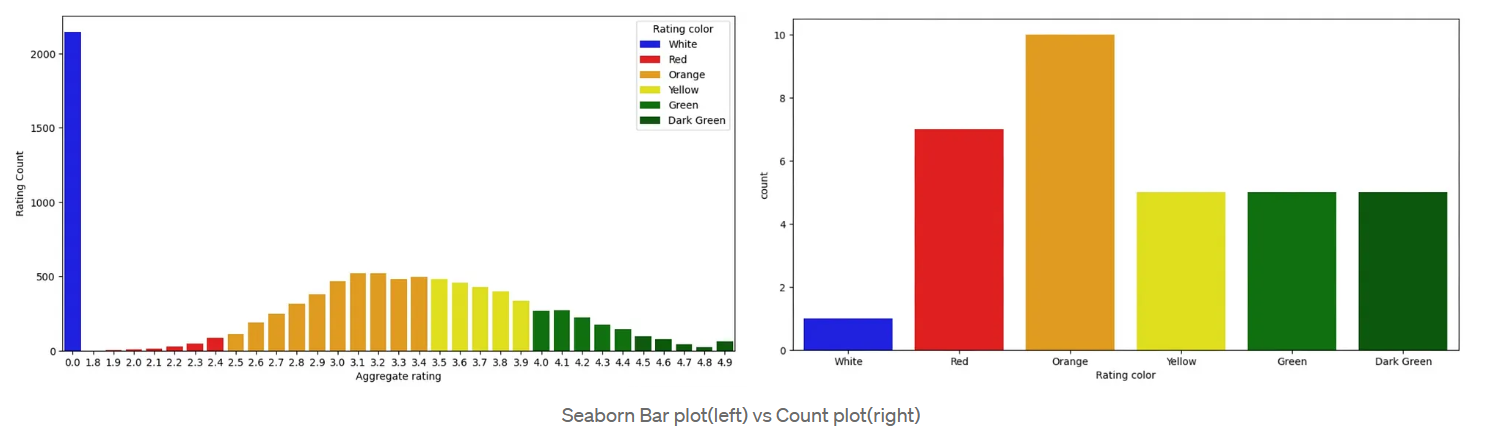

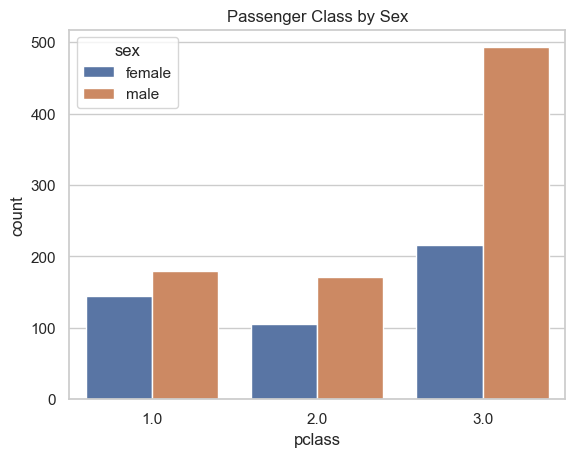

In [35]:
sns.countplot(data=titanic, x="pclass", hue="sex")
plt.title("Passenger Class by Sex")
plt.show()

# countplot counts how many records fall into each category
# It’s used for categorical data (not numbers you want to average) In this case, it counts # passengers.
# data=titanic
#Tells Seaborn which DataFrame to use
# x="pclass"
# This puts passenger class on the x-axis
# hue="sex"
# Splits each bar by gender


#### Task

Plot a count of incidents per AnimalClass. (using countplot)

Create a barplot showing the average incident cost (IncidentNominalCost(£)) per TypeOfIncident.   (using barplot)

Repeat the barplot but add a hue="AnimalClass" to compare mammals, birds, reptiles, and fish.

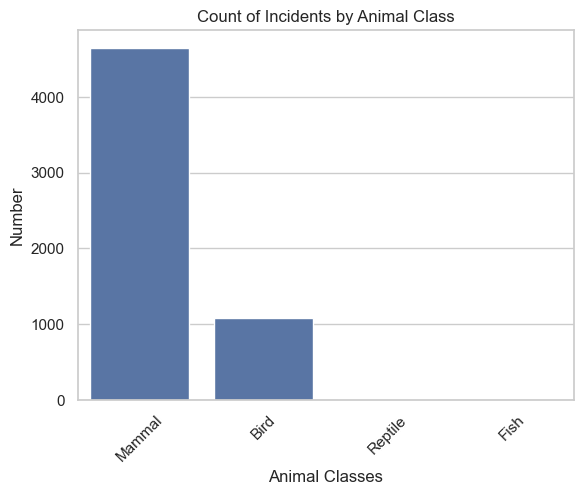

In [36]:
#ANSWERS
sns.countplot(data=animals, x="AnimalClass")
plt.title("Count of Incidents by Animal Class")
plt.xlabel("Animal Classes")
plt.ylabel("Number")
plt.xticks(rotation=45)
plt.show()

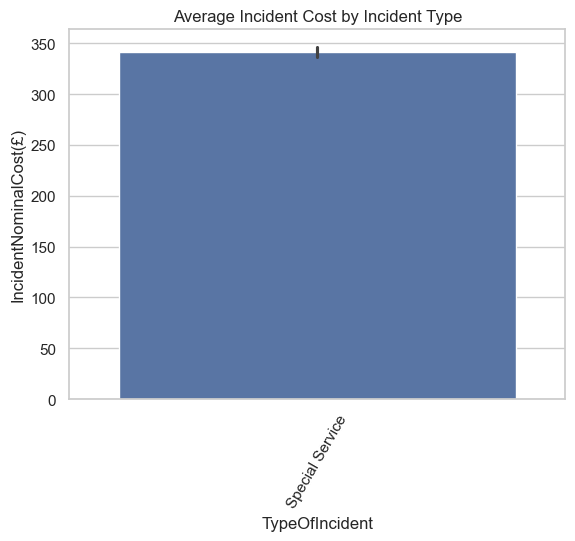

In [37]:
# 2. Average incident cost per TypeOfIncident
sns.barplot(data=animals, x="TypeOfIncident", y="IncidentNominalCost(£)")
plt.xticks(rotation=60)
plt.title("Average Incident Cost by Incident Type")
plt.show()

In the above there is only one type of Incident which is special service. This can be checked with the code below

In [38]:
animals["TypeOfIncident"].value_counts()

TypeOfIncident
Special Service    5752
Name: count, dtype: int64

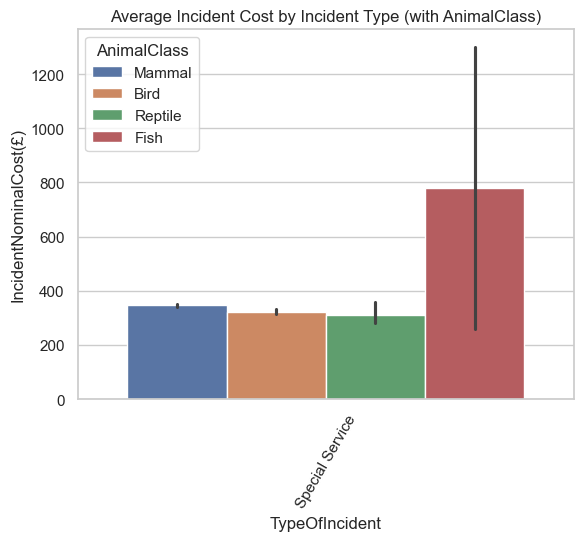

In [39]:
# 3. Same barplot but coloured by AnimalClass
sns.barplot(data=animals, x="TypeOfIncident", y="IncidentNominalCost(£)", hue="AnimalClass")
plt.xticks(rotation=60)
plt.title("Average Incident Cost by Incident Type (with AnimalClass)")
plt.show()

### B) Distribution Plots (lot more details next week)
- Histplot A histplot is a histogram plot used to show the distribution of numerical data — in other words, how values are spread out and how often they occur.

- KDE overlay (Kernal Density Estimate - the smoothed line on the top showing the shape of the line

- Split by hue

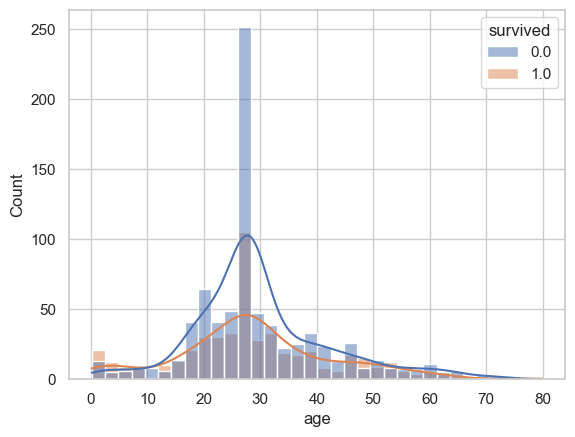

In [40]:
sns.histplot(data=titanic, x="age", hue="survived", kde=True)
plt.show()

There were lots of people around the age of 28 -not many over 60 -also a lot died. 

In [41]:
animals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   IncidentNumber              5752 non-null   object 
 1   DateTimeOfCall              5752 non-null   object 
 2   CalYear                     5752 non-null   int64  
 3   FinYear                     5752 non-null   object 
 4   TypeOfIncident              5752 non-null   object 
 5   PumpCount                   5716 non-null   float64
 6   PumpHoursTotal              5752 non-null   float64
 7   HourlyNominalCost(£)        5752 non-null   int64  
 8   IncidentNominalCost(£)      5716 non-null   float64
 9   FinalDescription            5749 non-null   object 
 10  AnimalGroupParent           5752 non-null   object 
 11  PropertyType                5752 non-null   object 
 12  SpecialServiceTypeCategory  5752 non-null   object 
 13  SpecialServiceType          5752 

### Task
Plot the distribution of PumpHoursTotal.

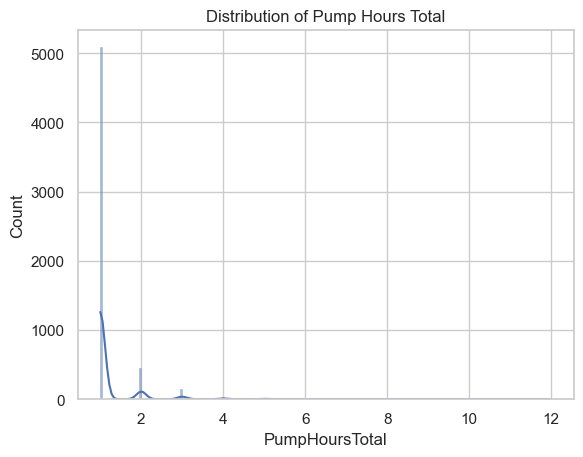

In [42]:
# Distribution of PumpHoursTotal
sns.histplot(data=animals, x="PumpHoursTotal", kde=True)
plt.title("Distribution of Pump Hours Total")
plt.show()

### C) Relationship Plots
- Scatter

- Box

- Violin

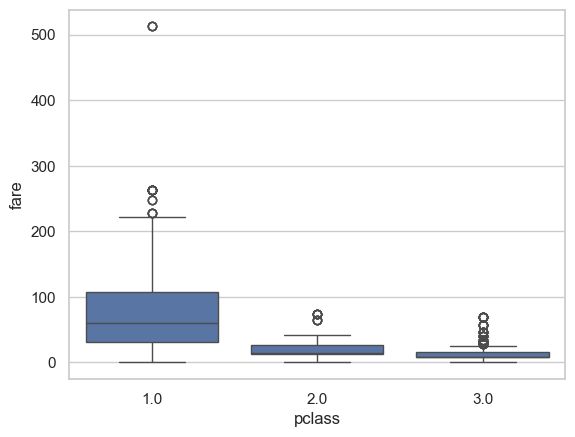

In [43]:
sns.boxplot(data=titanic, x="pclass", y="fare")
plt.show()

#### Tasks

Create a scatterplot of PumpHoursTotal vs IncidentNominalCost(£) coloured by AnimalClass.

Create a boxplot of IncidentNominalCost(£) by AnimalGroupParent.

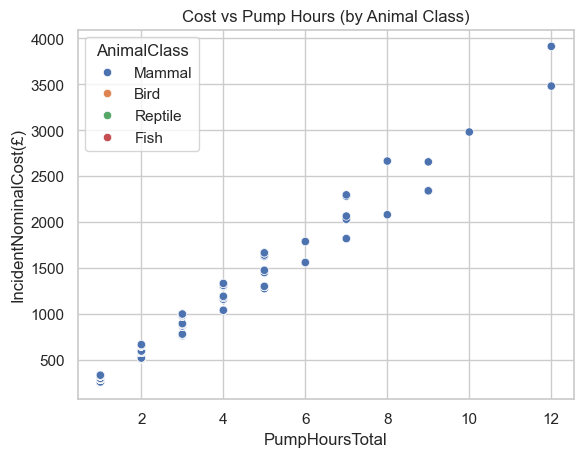

In [44]:
# 1. Scatterplot: PumpHoursTotal vs IncidentNominalCost(£)
sns.scatterplot(data=animals, x="PumpHoursTotal", y="IncidentNominalCost(£)",
                hue="AnimalClass")
plt.title("Cost vs Pump Hours (by Animal Class)")
plt.show()


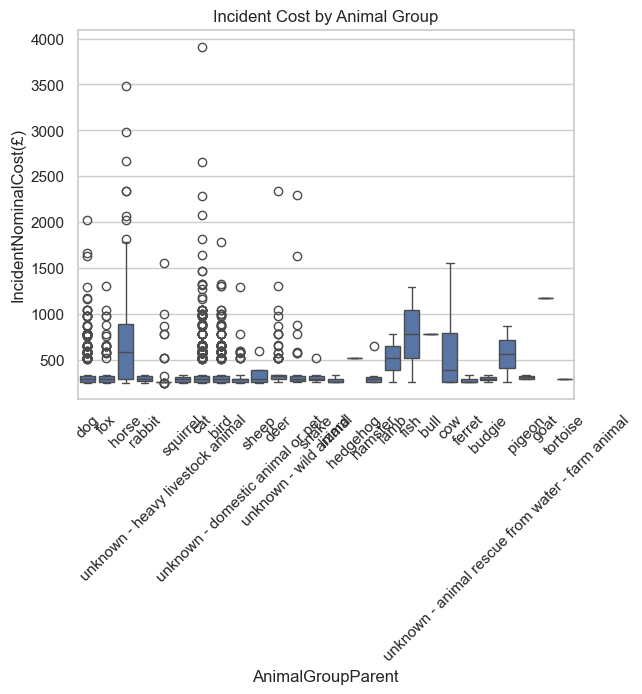

In [45]:
# 2. Boxplot of cost by animal group
sns.boxplot(data=animals, x="AnimalGroupParent", y="IncidentNominalCost(£)")
plt.xticks(rotation=45)
plt.title("Incident Cost by Animal Group")
plt.show()

### D) Correlation Heatmap
Good for quick Exploratory Data Analysis (EDA).

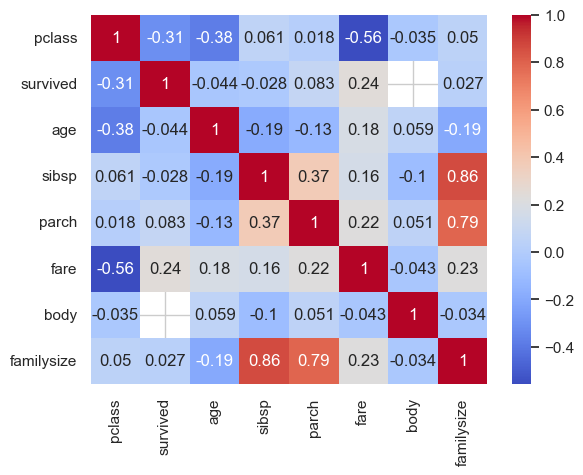

In [46]:
corr = titanic.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

#### Task
Create a correlation heatmap of all numeric columns in the animals dataset.

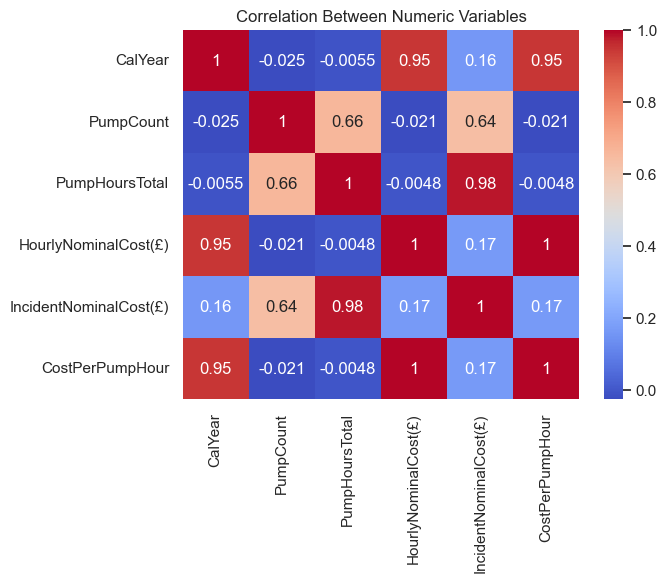

In [47]:
corr = animals.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Numeric Variables")
plt.show()